# 🌊 Уровень воды реки Миссисипи (St. Louis, 2015–2024)

Реальные данные с гидропоста **USGS #07010000** (Mississippi River at St. Louis, MO).
Источник: USGS Water Services — открытые данные, скачаны напрямую без регистрации.

- **Показатель:** `gage_height_ft` — уровень воды над нулём поста (футы)
- **Период:** 2015-01-01 … 2024-12-31 (суточные значения, 3604 дня)

> Данные уже скачаны в файл `mississippi_water_level.csv` (рядом с ноутбуком).
> Если нужно перекачать — раскомментируй ячейку «Скачать заново» ниже.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# при необходимости скачать заново:
# import urllib.request
# url = ("https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites=07010000"
#        "&startDT=2015-01-01&endDT=2024-12-31&parameterCd=00065")
# raw = pd.read_csv(url, sep='\t', comment='#').drop(0)
# col = [c for c in raw.columns if '00065' in c and not c.endswith('_cd')][0]
# raw = raw.rename(columns={'datetime':'date', col:'gage_height_ft'})[['date','gage_height_ft']]
# raw.to_csv('mississippi_water_level.csv', index=False)

df = pd.read_csv('mississippi_water_level.csv', parse_dates=['date'])
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
print('Размер:', df.shape)
df.head()

Размер: (3604, 4)


,date,gage_height_ft,Year,Month
0,2015-01-01,6.55,2015,1
1,2015-01-02,3.88,2015,1
2,2015-01-03,2.44,2015,1
3,2015-01-04,3.64,2015,1
4,2015-01-05,5.49,2015,1


## 1. Уровень воды за всё время

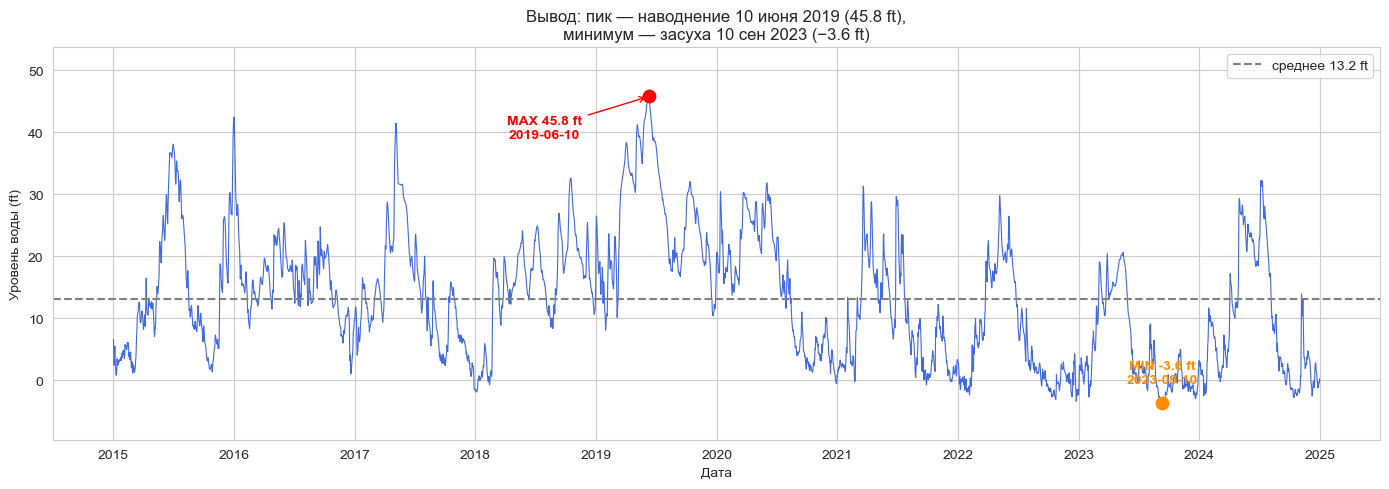

In [12]:
peak = df.loc[df['gage_height_ft'].idxmax()]   # максимум
low  = df.loc[df['gage_height_ft'].idxmin()]   # минимум

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['gage_height_ft'], color='royalblue', lw=0.8)
plt.axhline(df['gage_height_ft'].mean(), color='gray', ls='--', label='среднее 13.2 ft')

# запас сверху/снизу, чтобы подписи не налезали на заголовок и ось
plt.ylim(df['gage_height_ft'].min() - 6, df['gage_height_ft'].max() + 8)

# точка максимума (подпись слева-снизу от точки, со стрелкой)
plt.scatter(peak['date'], peak['gage_height_ft'], color='red', s=80, zorder=5)
plt.annotate(f"MAX {peak['gage_height_ft']:.1f} ft\n{peak['date'].date()}",
             xy=(peak['date'], peak['gage_height_ft']),
             xytext=(-75, -30), textcoords='offset points',
             ha='center', color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

# точка минимума
plt.scatter(low['date'], low['gage_height_ft'], color='darkorange', s=80, zorder=5)
plt.annotate(f"MIN {low['gage_height_ft']:.1f} ft\n{low['date'].date()}",
             xy=(low['date'], low['gage_height_ft']),
             xytext=(0, 14), textcoords='offset points',
             ha='center', color='darkorange', fontweight='bold')

plt.title('Вывод: пик — наводнение 10 июня 2019 (45.8 ft),\n'
          'минимум — засуха 10 сен 2023 (−3.6 ft)', fontsize=12)
plt.xlabel('Дата')
plt.ylabel('Уровень воды (ft)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Сезонность: средний уровень по месяцам

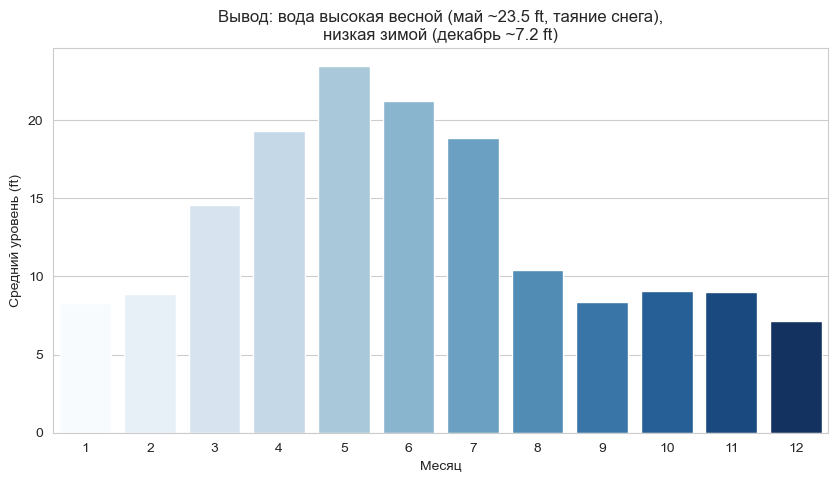

In [13]:
monthly = df.groupby('Month')['gage_height_ft'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values, hue=monthly.index,
            palette='Blues', legend=False)
plt.title('Вывод: вода высокая весной (май ~23.5 ft, таяние снега),\n'
          'низкая зимой (декабрь ~7.2 ft)', fontsize=12)
plt.xlabel('Месяц')
plt.ylabel('Средний уровень (ft)')
plt.show()

## 3. Средний уровень по годам — тренд

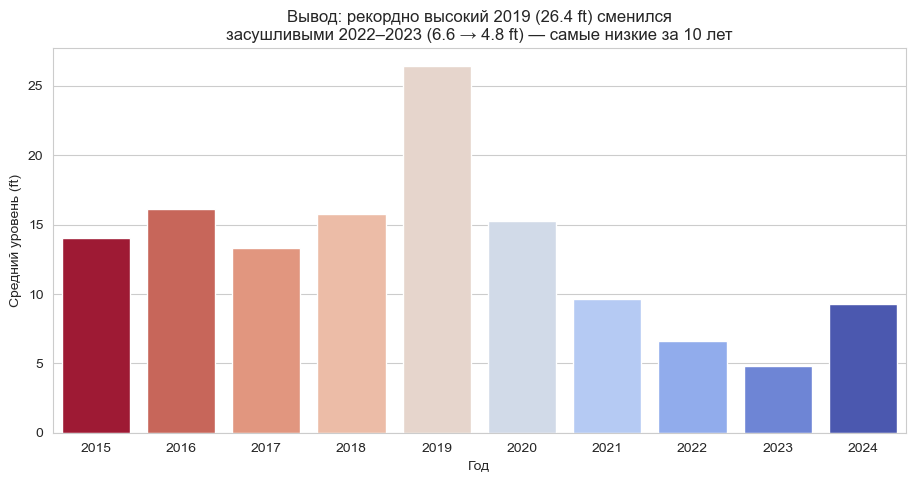

In [14]:
yearly = df.groupby('Year')['gage_height_ft'].mean()

plt.figure(figsize=(11, 5))
sns.barplot(x=yearly.index, y=yearly.values, hue=yearly.index,
            palette='coolwarm_r', legend=False)
plt.title('Вывод: рекордно высокий 2019 (26.4 ft) сменился\n'
          'засушливыми 2022–2023 (6.6 → 4.8 ft) — самые низкие за 10 лет', fontsize=12)
plt.xlabel('Год')
plt.ylabel('Средний уровень (ft)')
plt.show()

## 4. Распределение уровня по месяцам (boxplot)

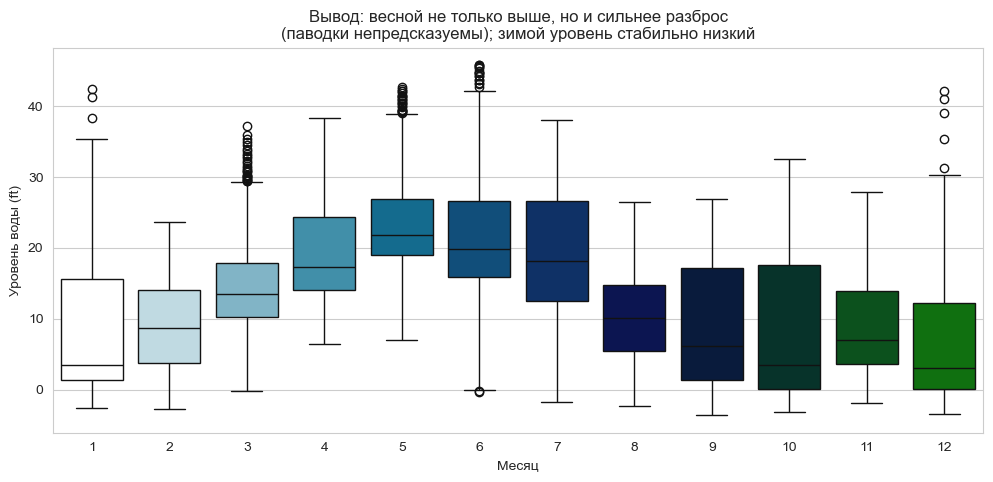

In [20]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Month', y='gage_height_ft', hue='Month',
            palette='ocean_r', legend=False)
plt.title('Вывод: весной не только выше, но и сильнее разброс\n'
          '(паводки непредсказуемы); зимой уровень стабильно низкий', fontsize=12)
plt.xlabel('Месяц')
plt.ylabel('Уровень воды (ft)')
plt.show()

## 📌 Итоговые выводы

1. **Рекордный пик** — 45.8 ft, 10 июня 2019 года (крупное наводнение Среднего Запада). **Минимум** — −3.6 ft, сентябрь 2023 (историческая засуха на Миссисипи).
2. **Чёткая сезонность**: уровень высокий весной (май ~23.5 ft — таяние снега и дожди), низкий зимой (декабрь ~7.2 ft).
3. **Тренд по годам**: после очень высокого 2019 (26.4 ft) пошло резкое падение — 2022 (6.6) и 2023 (4.8) стали самыми засушливыми за 10 лет.
4. **Разброс**: весной уровень не только выше, но и менее предсказуем (паводки), зимой — стабильно низкий.

*Источник: USGS Water Services, site 07010000 (Mississippi River at St. Louis).*